# SAMPLE_2 · 농산물 중금속 부적합 예측 (01 · 모델 학습)

**목표**: 농산물 검사 데이터를 학습해 이진분류 모델(`model.pkl`)을 만들어 02 폴더로 넘긴다.

**표준 워크플로우 (8단계)**: 로드 → EDA → 결측치 → 타겟분리·인코딩 → 분할(stratify) → 학습 → 평가(ROC-AUC) → 저장

### 데이터 출처
- 데이터셋: **농산물 중금속 분석결과** (국립농산물품질관리원, 2006~2020)
- 출처: **공공데이터포털 (data.go.kr)** — https://www.data.go.kr/data/15047544/fileData.do
- 제공기관: **농림축산식품부 국립농산물품질관리원** · 분류체계: 농림 - 임업·산촌 · 파일: **CSV**
- **이용허락범위: 제한 없음** (포털 상세페이지 표기 기준) — 출처만 밝히면 자유롭게 활용 가능
- 받는 법: 위 페이지 → 다운로드 (CSV, 로그인 불필요). 검사 1건 = 1행, 68,106건
- 공공데이터를 학습(교육) 목적으로 사용합니다.

**SAMPLE_1(화재)과 다른 점**: 이 데이터는 **지저분하다.** 같은 지역이 두 이름으로 적혀 있고(충남/충청남도),
품목이 518종이며, 재배면적은 29%가 비어 있다. **전처리가 이 실습의 진짜 주제다.**

## 1단계. 라이브러리 & 데이터 로드
라이브러리를 불러오고 CSV 를 읽는다. `분석결과` 열에 이미 **적합/부적합** 판정이 있으므로 그것으로 타겟을 만든다.

In [1]:
import pandas as pd, numpy as np, json, joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

plt.rcParams['font.family'] = 'Malgun Gothic'   # 그래프 한글이 깨지지 않게 (Windows)
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/농산물_중금속_분석결과.csv', encoding='cp949')

# 정답(타겟) 만들기 : '적합' 으로 시작하지 않으면 부적합(1)
TARGET = '부적합'
LABELS = ['적합', '부적합']
df[TARGET] = (~df['분석결과'].astype(str).str.startswith('적합')).astype(int)

print('데이터 크기(행, 열):', df.shape)
print(df['분석결과'].value_counts())
df.head()

데이터 크기(행, 열): (68106, 9)
분석결과
적합                       67345
부적합 (폐기)                   749
부적합(회수폐기 및 생산 단계 재조사)       12
Name: count, dtype: int64


,품목명,수거단계,재배양식,생산자 주소,재배면적,조사물량,등록일자,분석결과,부적합
0,참깨,생산,일반,충청북도 보은군,3743.0,200.0,20200831,적합,0
1,무,생산,일반,경상북도 봉화군,3581.0,21000.0,20200827,적합,0
2,무,생산,일반,경상북도 봉화군,674.0,6127.0,20200827,적합,0
3,둥글래,생산,일반,경상북도 봉화군,3080.0,300.0,20200827,적합,0
4,오미자,생산,일반,경상북도 봉화군,2261.0,3425.0,20200827,적합,0


## 2단계. EDA - 데이터 파악
타겟 분포·결측치와 함께 **범주형 열의 상태**를 확인한다. 여기서 지저분한 부분이 드러난다.

[타겟 분포]
부적합
0    67345
1      761
Name: count, dtype: int64
부적합 비율: 0.0112

[결측치 개수]
품목명           0
수거단계          0
재배양식          0
생산자 주소        0
재배면적      19932
조사물량      12975
등록일자          0
분석결과          0
부적합           0
dtype: int64

[범주형 열의 고유값 개수]
  품목명          518종
  수거단계           4종
  재배양식          12종
  생산자 주소       469종


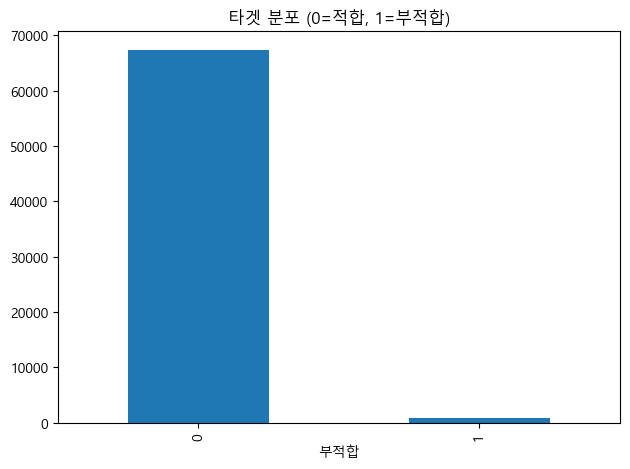

In [2]:
print('[타겟 분포]')
print(df[TARGET].value_counts())
print('부적합 비율:', round(df[TARGET].mean(), 4))

print('\n[결측치 개수]')
print(df.isnull().sum())

print('\n[범주형 열의 고유값 개수]')
for c in ['품목명', '수거단계', '재배양식', '생산자 주소']:
    print('  %-10s %5d종' % (c, df[c].nunique()))

df[TARGET].value_counts().sort_index().plot(kind='bar', title='타겟 분포 (0=적합, 1=부적합)')
plt.tight_layout(); plt.show()

**관찰 - 세 가지 문제**
1. **극심한 불균형**: 부적합이 약 1.1% 뿐. SAMPLE_1(3.9%)보다 더 심하다 → 정확도는 볼 것도 없다.
2. **품목명 518종**: 대부분 몇 건뿐인 희소 품목이다. 그대로 쓰면 모델이 배울 근거가 없다.
3. **결측**: 재배면적 29%, 조사물량 19% 가 비어 있다.

3단계에서 **더 큰 문제**가 하나 더 나온다.

## 3단계. 전처리 - 데이터 정제 & 결측치
이 단계가 SAMPLE_2 의 핵심이다. 먼저 **앞뒤 공백**부터 지운다 — `'일반 '` 처럼 공백이 붙어 있으면 `'일반'` 과 다른 값으로 취급된다. **정제 → 희소범주 묶기** 를 하고, 결측치는 **5단계 분할 뒤에** 채운다(누수 방지).

In [3]:
# (0) 문자열 앞뒤 공백 제거 — 실무 데이터의 기본 정제
for c in ['품목명', '수거단계', '재배양식', '생산자 주소', '분석결과']:
    df[c] = df[c].astype(str).str.strip()

# (1) 생산자 주소에서 시도 추출
df['시도'] = df['생산자 주소'].astype(str).str.split().str[0]
print('[정제 전] 시도 %d종' % df['시도'].nunique())
print(df['시도'].value_counts().head(8).to_dict())

[정제 전] 시도 33종
{'충남': 5933, '경북': 5932, '경상북도': 5671, '충청남도': 5316, '경남': 4361, '전남': 4204, '경상남도': 4025, '강원도': 3934}


**문제 발견**: `충남` 과 `충청남도` 가 **따로** 집계된다. 같은 지역인데 표기가 다른 것이다.
(`경북`/`경상북도`, `서울`/`서울특별시` 등도 마찬가지)

이대로 두면 모델은 충남과 충청남도를 **다른 지역으로 배운다.** 데이터가 쪼개져 둘 다 제대로 못 배운다.
**표기를 통일해야 한다.**

In [4]:
# (2) 시도 표기 통일 — 축약형을 정식 명칭으로
SIDO = {'충남':'충청남도', '충북':'충청북도', '경남':'경상남도', '경북':'경상북도',
        '전남':'전라남도', '전북':'전라북도', '강원':'강원도', '경기':'경기도',
        '제주':'제주특별자치도', '서울':'서울특별시', '부산':'부산광역시', '대구':'대구광역시',
        '인천':'인천광역시', '광주':'광주광역시', '대전':'대전광역시', '울산':'울산광역시',
        '세종':'세종특별자치시'}
df['시도'] = df['시도'].replace(SIDO)
print('[정제 후] 시도 %d종' % df['시도'].nunique())

# (3) 희소 범주 묶기 : 품목 상위 30개만 남기고 나머지는 '기타'
top30 = df['품목명'].value_counts().head(30).index
df['품목'] = np.where(df['품목명'].isin(top30), df['품목명'], '기타')
print("품목: 518종 -> %d종 ('기타' 비중 %.1f%%)" % (df['품목'].nunique(), 100*(df['품목']=='기타').mean()))

# 재배양식도 상위 5개 + 기타
top5 = df['재배양식'].value_counts().head(5).index
df['양식'] = np.where(df['재배양식'].isin(top5), df['재배양식'], '기타')

# (4) 날짜에서 월, 수치형 변환
df['month'] = pd.to_datetime(df['등록일자'], format='%Y%m%d', errors='coerce').dt.month
df['area']   = pd.to_numeric(df['재배면적'], errors='coerce')
df['volume'] = pd.to_numeric(df['조사물량'], errors='coerce')

before = len(df)
df = df.dropna(subset=['품목', '수거단계', '양식', '시도', 'month', TARGET])
print('결측 행 제거: %d행 -> %d행  (면적·물량의 결측은 5단계 뒤에 채운다)' % (before, len(df)))

[정제 후] 시도 17종
품목: 518종 -> 31종 ('기타' 비중 24.0%)
결측 행 제거: 68106행 -> 68106행  (면적·물량의 결측은 5단계 뒤에 채운다)


**중급 포인트 (누수 방지) - 왜 결측을 지금 안 채우나**
`area`(재배면적)는 29%가 비어 있다. 중앙값으로 채워야 하는데 **지금 전체 데이터의 중앙값으로 채우면 안 된다.**
그 중앙값에는 **검증 데이터의 정보가 섞여** 있기 때문이다(데이터 누수). 성능이 실제보다 좋아 보인다.

그래서 **5단계에서 분할한 뒤, 학습 데이터의 중앙값으로 양쪽을 채운다.**
SAMPLE_1 은 결측이 없어 넘어갔지만, 이 데이터는 실제로 해봐야 한다.

### 3-1. 인사이트 도출 — 데이터가 말하는 것

정제를 끝냈으니 이제 데이터에게 물어본다. **"어떤 조건일 때 부적합이 나오는가?"**
범주별 부적합률을 집계하면 숫자가 대답해 준다. 여기서 읽은 것을 **7단계에서 모델과 대조**한다.

(정제 **후에** 집계하는 이유 — 정제 전이라면 `충남`과 `충청남도`가 따로 잡혀 같은 지역의 비율이 둘로 쪼개진다.)

전체 부적합률 : 1.12%   <- 이 값이 기준선

[수거단계]  상위 3 / 하위 2  (200건 이상 범주만)
   생산                1.55%   n= 48183   기준선의  1.39배
   유통/판매             0.06%   n= 19815   기준선의  0.05배
   생산                1.55%   n= 48183   기준선의  1.39배
   유통/판매             0.06%   n= 19815   기준선의  0.05배

[양식]  상위 3 / 하위 2  (200건 이상 범주만)
   일반                1.17%   n= 65124   기준선의  1.04배
   GAP(인증)           0.28%   n=   355   기준선의  0.25배
   직불제(쌀소득)          0.00%   n=   532   기준선의  0.00배
   친환경(인증) 무농약       0.00%   n=  1643   기준선의  0.00배
   친환경(인증) 유기        0.00%   n=   260   기준선의  0.00배

[품목]  상위 3 / 하위 2  (200건 이상 범주만)
   백태                3.63%   n=  1241   기준선의  3.25배
   멥쌀(일반)            2.08%   n= 16084   기준선의  1.86배
   현미                1.89%   n= 12121   기준선의  1.69배
   찰옥수수(대학찰,먹찰)      0.00%   n=  1046   기준선의  0.00배
   흙당근               0.00%   n=   820   기준선의  0.00배

[시도]  상위 3 / 하위 2  (200건 이상 범주만)
   부산광역시             4.98%   n=  1346   기준선의  4.45배
   대구광역시             2.48%   n=   565   기준선의  2.22배


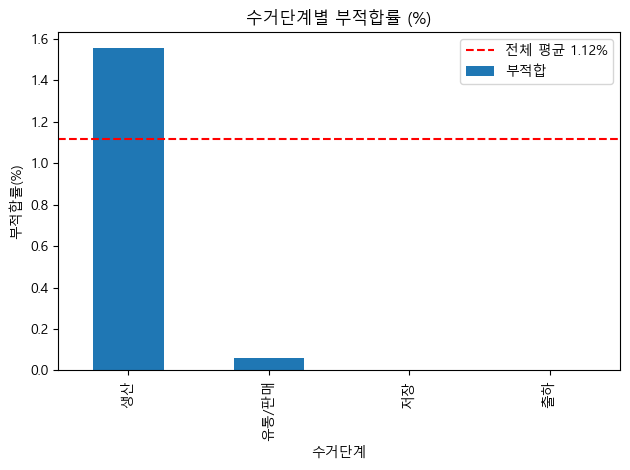

In [5]:
# 범주별 양성비율(부적합률)을 집계한다.
BASE = df[TARGET].mean()
print('전체 부적합률 : %.2f%%   <- 이 값이 기준선' % (BASE * 100))

for col in ['수거단계', '양식', '품목', '시도']:
    t = df.groupby(col)[TARGET].agg(['mean', 'count'])
    t = t[t['count'] >= 200].sort_values('mean', ascending=False)
    print('\n[%s]  상위 3 / 하위 2  (200건 이상 범주만)' % col)
    for name, r in pd.concat([t.head(3), t.tail(2)]).iterrows():
        print('   %-16s %5.2f%%   n=%6d   기준선의 %5.2f배'
              % (str(name)[:16], r['mean'] * 100, r['count'], r['mean'] / BASE))

# 수거단계별 부적합률 — 가장 크게 갈리는 항목
s = df.groupby('수거단계')[TARGET].mean() * 100
s.sort_values(ascending=False).plot(kind='bar', title='수거단계별 부적합률 (%)')
plt.axhline(BASE * 100, color='red', ls='--', label='전체 평균 %.2f%%' % (BASE * 100))
plt.ylabel('부적합률(%)')
plt.legend(); plt.tight_layout(); plt.show()

**인사이트 (위 출력에서 읽은 것)**

1. **수거단계가 압도적으로 갈린다.** `생산` 1.55% vs `유통/판매` 0.06% — **약 26배**다.
   밭에서 캐자마자 검사하면 부적합이 나오지만, 유통 단계까지 올라온 것은 이미 걸러진 뒤다.
   → **검사 시점이 결과를 좌우한다.**
2. **친환경·직불제 인증은 부적합이 0.00%** 다 (무농약 1,643건 · 유기 260건 · 직불제 532건 **전부 적합**).
   반면 `일반` 재배는 1.17%. → 인증 관리가 실제로 작동하고 있다.
3. **품목은 곡물이 위험하다.** `백태` 3.63%(3.3배) · `멥쌀(일반)` 2.08% · `현미` 1.89%.
   토양의 중금속을 오래 흡수하는 작물이라는 해석과 맞는다.
4. **지역은 부산이 튄다.** `부산광역시` 4.98% (4.5배) · `대구광역시` 2.48%. 폐광산·공단 인접지가 의심된다.

→ 정리하면 **"생산 단계에서 수거한, 일반 재배 곡물, 특히 부산·대구산"** 이 위험하다.

## 4단계. 타겟 분리 & 인코딩
글자로 된 항목을 숫자 코드로 바꾸고, 입력(X)과 정답(y)을 나눈다.

In [6]:
# 코드 열 이름은 영문으로. 이 이름이 그대로 API 의 JSON 키가 된다.
# 한글 키는 터미널에서 인코딩이 깨져 오류가 난다. (보이는 이름은 label 이 담당)
CODE = {'품목': 'item', '수거단계': 'stage', '양식': 'method', '시도': 'sido'}
CATS = list(CODE.keys())

OPTIONS = {}
for c in CATS:
    OPTIONS[c] = sorted(df[c].astype(str).unique())
    df[CODE[c]] = df[c].astype(str).map({v: i for i, v in enumerate(OPTIONS[c])})

FEATURES = [
    {'name': 'item',   'label': '품목',         'kind': 'cat', 'options': OPTIONS['품목']},
    {'name': 'stage',  'label': '수거단계',      'kind': 'cat', 'options': OPTIONS['수거단계']},
    {'name': 'method', 'label': '재배양식',      'kind': 'cat', 'options': OPTIONS['양식']},
    {'name': 'sido',   'label': '생산지(시도)',   'kind': 'cat', 'options': OPTIONS['시도']},
    {'name': 'month',  'label': '검사 월',       'kind': 'num'},
    {'name': 'area',   'label': '재배면적(㎡)',   'kind': 'num'},
    {'name': 'volume', 'label': '조사물량(kg)',  'kind': 'num'},
]

X = df[[f['name'] for f in FEATURES]]
y = df[TARGET].astype(int)
print('입력 X:', X.shape, '| 정답 y:', y.shape)
print('아직 남은 결측:', X.isnull().sum()[X.isnull().sum() > 0].to_dict())
X.head()

입력 X: (68106, 7) | 정답 y: (68106,)
아직 남은 결측: {'area': 19932, 'volume': 12975}


,item,stage,method,sido,month,area,volume
0,3,0,2,16,8,3743.0,200.0
1,11,0,2,3,8,3581.0,21000.0
2,11,0,2,3,8,674.0,6127.0
3,3,0,2,3,8,3080.0,300.0
4,3,0,2,3,8,2261.0,3425.0


**중급 포인트 (누수) - 무엇을 입력에서 빼나**
`분석결과` 는 **타겟 그 자체**라 반드시 뺀다. 남긴 7개는 **검사 전에 알 수 있는 정보**뿐이다 —
무슨 품목을, 어느 단계에서, 어떤 재배방식으로, 어디서, 언제, 얼마나 재배·수거했는가.

## 5단계. 검증 데이터 분할 & 결측치 채우기
분할을 **먼저** 하고, **학습 데이터의 중앙값으로** 양쪽의 결측을 채운다. 순서가 중요하다.

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 결측 채우기 : 반드시 '학습 데이터(X_tr)' 의 중앙값으로 양쪽을 채운다 (누수 방지)
X_tr, X_te = X_tr.copy(), X_te.copy()
for c in ['area', 'volume']:
    m = X_tr[c].median()                # <- 전체가 아니라 학습 데이터 기준!
    X_tr[c] = X_tr[c].fillna(m)
    X_te[c] = X_te[c].fillna(m)
    print('%-7s 중앙값 %8.0f 로 채움' % (c, m))

print()
print('학습:', X_tr.shape, '| 검증:', X_te.shape)
print('학습 부적합 비율:', round(y_tr.mean(), 4), '| 검증 부적합 비율:', round(y_te.mean(), 4))
print('남은 결측:', int(X_tr.isnull().sum().sum()), int(X_te.isnull().sum().sum()))

area    중앙값     1432 로 채움
volume  중앙값      500 로 채움

학습: (54484, 7) | 검증: (13622, 7)
학습 부적합 비율: 0.0112 | 검증 부적합 비율: 0.0112
남은 결측: 0 0


## 6단계. 모델 학습 - 랜덤포레스트
부적합이 1.1% 뿐이라 `class_weight='balanced'` 가 **필수**다. 없으면 "전부 적합"이라고만 답한다.

In [8]:
model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42,
                               n_jobs=-1, class_weight='balanced')
model.fit(X_tr, y_tr)
print('학습 완료:', model)

학습 완료: RandomForestClassifier(class_weight='balanced', max_depth=8, n_jobs=-1,
                       random_state=42)


## 7단계. 평가 - 정확도 vs ROC-AUC
정확도와 ROC-AUC 를 함께 보고, `class_weight` 를 뺀 모델과 비교한다.

정확도(Accuracy): 0.6519
  전부 "적합"으로 찍기만 해도 : 0.9888   <- 정확도의 함정
ROC-AUC        : 0.8147   <- 진짜 실력 (0.5 = 찍기)

              precision    recall  f1-score   support

          적합       1.00      0.65      0.79     13470
         부적합       0.03      0.86      0.05       152

    accuracy                           0.65     13622
   macro avg       0.51      0.76      0.42     13622
weighted avg       0.99      0.65      0.78     13622



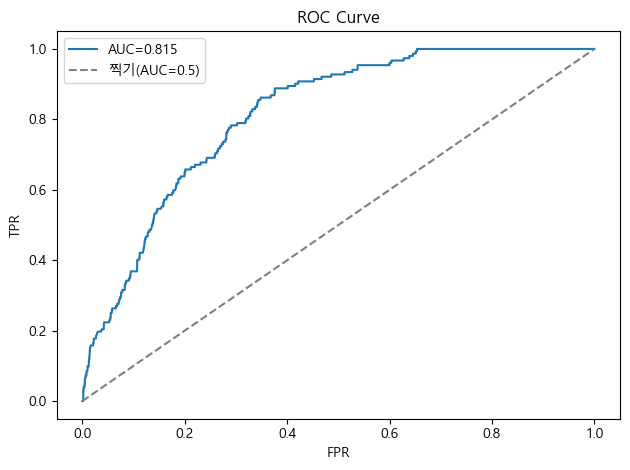

In [9]:
pred  = model.predict(X_te)
proba = model.predict_proba(X_te)[:, 1]      # 양성(부적합) 확률 열

acc  = accuracy_score(y_te, pred)
auc  = roc_auc_score(y_te, proba)
base = 1 - y_te.mean()

print('정확도(Accuracy):', round(acc, 4))
print('  전부 "적합"으로 찍기만 해도 :', round(base, 4), '  <- 정확도의 함정')
print('ROC-AUC        :', round(auc, 4), '  <- 진짜 실력 (0.5 = 찍기)')
print()
print(classification_report(y_te, pred, target_names=LABELS, zero_division=0))

fpr, tpr, _ = roc_curve(y_te, proba)
plt.plot(fpr, tpr, label='AUC=%.3f' % auc)
plt.plot([0, 1], [0, 1], '--', color='gray', label='찍기(AUC=0.5)')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve')
plt.legend(); plt.tight_layout(); plt.show()

### 비교 : `class_weight='balanced'` 를 빼면 어떻게 되나

In [10]:
plain = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
plain.fit(X_tr, y_tr)
p_pred  = plain.predict(X_te)
p_proba = plain.predict_proba(X_te)[:, 1]

rep_p = classification_report(y_te, p_pred, target_names=LABELS, zero_division=0, output_dict=True)
rep_b = classification_report(y_te, pred,   target_names=LABELS, zero_division=0, output_dict=True)

print('%-26s %10s %10s' % ('', 'balanced 안씀', 'balanced 씀'))
print('%-26s %10.4f %10.4f' % ('정확도',              accuracy_score(y_te, p_pred), acc))
print('%-26s %10.4f %10.4f' % ('ROC-AUC',             roc_auc_score(y_te, p_proba), auc))
print('%-26s %10.3f %10.3f' % ("'부적합' recall",       rep_p[LABELS[1]]['recall'],  rep_b[LABELS[1]]['recall']))
print('%-26s %10d %10d' % ("'부적합' 이라고 예측한 수",  int(p_pred.sum()), int(pred.sum())))
print('%-26s %10d %10d' % ('실제 부적합 건수',           int(y_te.sum()), int(y_te.sum())))

                           balanced 안씀 balanced 씀
정확도                            0.9888     0.6519
ROC-AUC                        0.8228     0.8147
'부적합' recall                    0.000      0.862
'부적합' 이라고 예측한 수                     0       4852
실제 부적합 건수                         152        152


**결과 해석**
- `balanced` 를 안 쓰면 정확도 0.98 대인데 **부적합을 단 한 건도 못 잡는다**(recall 0.000, 양성 예측 0건).
  전부 "적합"이라 찍었기 때문이다. **검사 기관이 쓸 수 없는 모델**이다.
- `balanced` 를 쓰면 정확도는 크게 떨어지지만 **부적합의 86% 를 잡아낸다.** 대신 헛경보가 많다.
- 식품 안전에서는 **부적합을 놓치는 것이 헛경보보다 훨씬 위험**하다. 이 교환은 타당하다.
- 헛경보가 많은 모델은 "정밀 검사 대상을 1차로 걸러내는 용도"로 쓴다. 최종 판정은 사람이 한다.

### 7-2. 인사이트 대조 — 데이터에서 읽은 것을 모델도 배웠나

[특성 중요도] 모델이 실제로 많이 쓴 입력
   stage        0.231
   month        0.204
   volume       0.172
   item         0.154
   area         0.136
   sido         0.080
   method       0.023


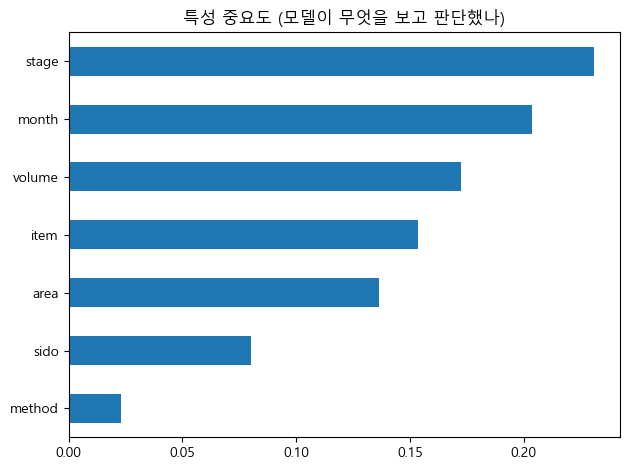

In [11]:
# 2단계에서 데이터로 읽은 인사이트를, 모델이 실제로 그렇게 배웠는지 대조한다.
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('[특성 중요도] 모델이 실제로 많이 쓴 입력')
for k, v in imp.items():
    print('   %-12s %.3f' % (k, v))

imp.sort_values().plot(kind='barh', title='특성 중요도 (모델이 무엇을 보고 판단했나)')
plt.tight_layout(); plt.show()

**대조 결과 — 일치하는 것과 어긋나는 것**

`stage`(수거단계)가 **0.231 로 1위**다. 3-1단계에서 **26배 차이**(생산 1.55% vs 유통/판매 0.06%)가 났던
그 항목이다. → **일치한다.**

그런데 **어긋나는 것이 있다. 이쪽이 더 중요한 교훈이다.**

- `method`(재배양식)는 3-1단계에서 **"친환경·직불제 인증은 부적합 0.00%"** 라는 가장 극적인 차이를 보였는데,
  중요도는 **0.023 으로 꼴찌**다.
  이유는 **건수**다. 친환경 무농약(1,643) + 유기(260) + 직불제(532) + GAP(355) 를 다 합쳐도 2,790건,
  **전체 68,106건의 4%뿐**이다. 비율 차이가 아무리 커도 **건수가 적으면 모델은 거의 쓰지 않는다.**
- 반대로 `month`(0.204) · `volume`(0.172) · `area`(0.136) 는 3-1단계에서 범주로 집계하지 않았는데 상위권이다.
  수치형이라 모델이 잘게 자를 수 있기 때문이다.

**여기서 얻는 실무 감각** — 특성 중요도는 "정답" 이 아니다. 둘은 **다른 질문에 답한다.**

| | 묻는 것 | 답 |
|---|---|---|
| 범주별 양성비율 (인사이트) | 이 조건이면 위험한가? | 친환경이면 안전하다 |
| 특성 중요도 | 전체를 가르는 데 쓸모 있나? | 친환경인 경우가 드물어 별 쓸모 없다 |

**둘 다 맞다.** 어긋난다고 틀린 게 아니라, 무엇을 물었는지가 다른 것이다.

## 8단계. 모델 저장
학습된 모델과 입력 정의를 **02 폴더**에 저장한다.

In [12]:
TITLE = '농산물 중금속 부적합 예측'
DESC  = '품목·수거단계·재배양식·생산지·시기를 입력하면 중금속 검사에서 부적합이 나올지 예측합니다.'

for f in FEATURES:                 # 수치형 입력 범위 자동 계산
    if f['kind'] == 'num':
        s = X_tr[f['name']]
        f.update(min=int(np.floor(s.min())), max=int(np.ceil(s.quantile(0.99))),
                 default=int(round(s.median())))

spec = {'title': TITLE, 'description': DESC, 'target_labels': LABELS,
        'accuracy': round(float(acc), 4), 'roc_auc': round(float(auc), 4), 'features': FEATURES}

joblib.dump(model, '../02/model.pkl')
json.dump(spec, open('../02/feature_spec.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
print('저장 완료: ../02/model.pkl, ../02/feature_spec.json')

# 이 모델을 만든 환경의 버전 (02/requirements.txt 와 같아야 model.pkl 을 읽을 수 있다)
import sklearn, sys
print()
print('--- 이 model.pkl 을 만든 환경 ---')
print('python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('joblib      :', joblib.__version__)

저장 완료: ../02/model.pkl, ../02/feature_spec.json



--- 이 model.pkl 을 만든 환경 ---
python      : 3.11.0
numpy       : 2.4.6
pandas      : 3.0.3
scikit-learn: 1.9.0
joblib      : 1.5.3


---
### 정리 (뼈대 워크플로우)
로드 → EDA → **정제·희소범주** → 타겟분리·인코딩 → **분할 후 결측 채우기(train 기준)** → 학습 → 평가(ROC-AUC) → 저장

### SAMPLE_2 에서 꼭 가져갈 것
1. **데이터는 지저분하다.** 같은 지역이 두 이름(충남/충청남도)이면 모델은 다른 지역으로 배운다. **정제가 먼저다.**
2. **희소 범주는 묶는다.** 518종을 그대로 쓰면 대부분 몇 건뿐이라 배울 게 없다. 상위 30개 + 기타.
3. **결측은 분할 뒤 학습 데이터 기준으로 채운다.** 전체 중앙값으로 채우면 누수다.
4. 불균형(1.1%)에서 정확도는 착시. **ROC-AUC 와 recall** 을 본다.

### 다음 (02)
`../02` 의 **FastAPI** 가 `model.pkl` · `feature_spec.json` 을 읽어 예측 엔드포인트와 이력 CRUD 를 제공한다.
`uvicorn main:app --port 8002` 실행 후 `http://localhost:8002/docs` 에서 확인한다.